# Composer Demo: Convergence Comparison with Canonical Initialization

This notebook compares convergence across five MalthusJAX pipelines using a shared initial population and 30 seeds. The configuration is defined in `bench_engine_convergence.toml` and loaded with `Composer.from_toml()`.


In [1]:
from pathlib import Path

from malthusjax.composer import Composer

notebook_dir = Path.cwd()
toml_path = notebook_dir / "bench_engine_convergence.toml"
print(f"Loading TOML from: {toml_path}")
print("Using canonical shared initialization and Composer.from_toml()")

Loading TOML from: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX/examples/_DEMO_COMPOSER/bench_engine_convergence.toml
Using canonical shared initialization and Composer.from_toml()


In [2]:
# Shared experiment settings
fitness = "ellipsoidal_rotated:dim=100"
pop_size = 100
generations = 100
bounds = [-5.0, 5.0]
genome_length = 100

seeds = tuple(range(42, 142))  # 100 seeds

print(f"Configured {len(seeds)} seeds")

Configured 100 seeds


## Comparison Pipelines

This experiment compares three MalthusJAX pipelines with canonical shared initialization across 30 seeds.
- `malthusjax_default`: standard MalthusJAX with elite-pool selection.
- `malthusjax_roulette_evosaxops`: roulette selection with Evosax wrapper operators.
- `malthusjax_tournament_evosaxops`: tournament selection with Evosax wrapper operators.

In [3]:
comparison = Composer.from_toml(
    str(toml_path),
    shared_initial_population=True,
    pop_seed=123,
)

print(f"Pipelines loaded: {comparison.names}")
print(f"Seeds used: {len(seeds)}")

pipelines: 100%|██████████| 6/6 [01:43<00:00, 17.17s/it]

Pipelines loaded: ['malthusjax_default', 'malthusjax_roulette_evosaxops', 'malthusjax_tournament_evosaxops', 'evosax_simplega', 'evosax_mr15_ga', 'evosax_differential_evolution']
Seeds used: 100


In [4]:
summary = comparison.summary_table()

print("Aggregated summary:")
for pipeline_name, metrics in summary.items():
    best_fitness = metrics.get("best_fitness")
    print(f"- {pipeline_name}: best_fitness mean={best_fitness:.6f}")

seed_index = 0
seed_history = comparison.convergence_data(seed_index=seed_index)
print(f"\nConvergence history available for seed {seed_index}:")
for pipeline_name, history in seed_history.items():
    print(f"- {pipeline_name}: {len(history)} generations")

Aggregated summary:
- malthusjax_default: best_fitness mean=-193.855494
- malthusjax_roulette_evosaxops: best_fitness mean=-193.660260
- malthusjax_tournament_evosaxops: best_fitness mean=-193.779128
- evosax_simplega: best_fitness mean=-189.512240
- evosax_mr15_ga: best_fitness mean=-193.854481
- evosax_differential_evolution: best_fitness mean=-193.853491

Convergence history available for seed 0:
- malthusjax_default: 100 generations
- malthusjax_roulette_evosaxops: 100 generations
- malthusjax_tournament_evosaxops: 100 generations
- evosax_simplega: 100 generations
- evosax_mr15_ga: 100 generations
- evosax_differential_evolution: 100 generations


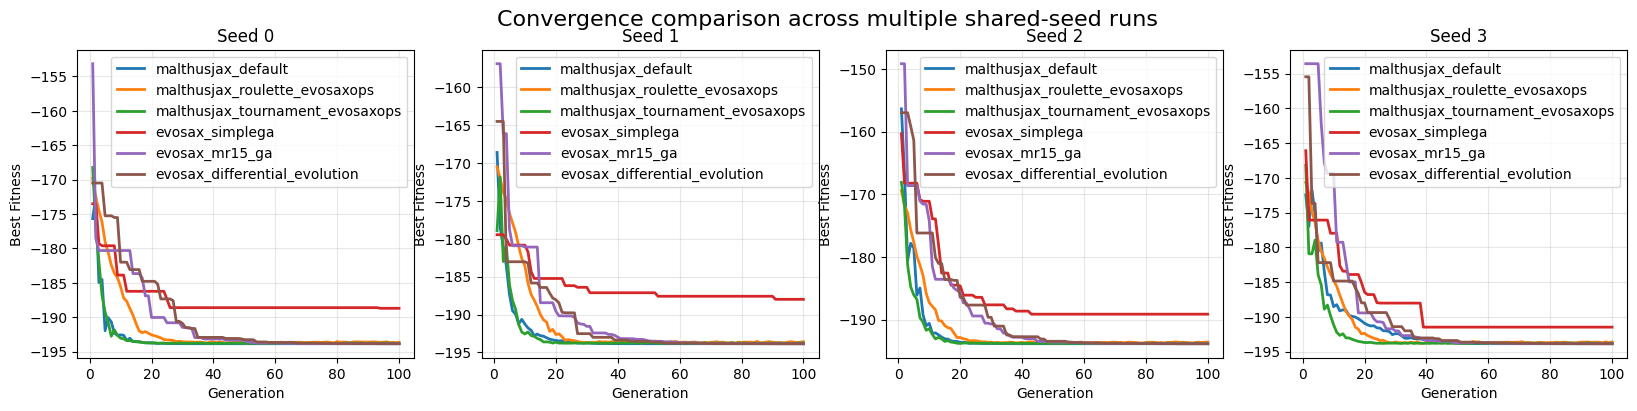

In [5]:
import matplotlib.pyplot as plt

seed_count = min(4, len(seeds))
seed_list = list(range(seed_count))

axes = comparison.plot_convergence(seed_index=seed_list)
for ax in axes:
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best Fitness")

plt.suptitle("Convergence comparison across multiple shared-seed runs", fontsize=16)
plt.show()

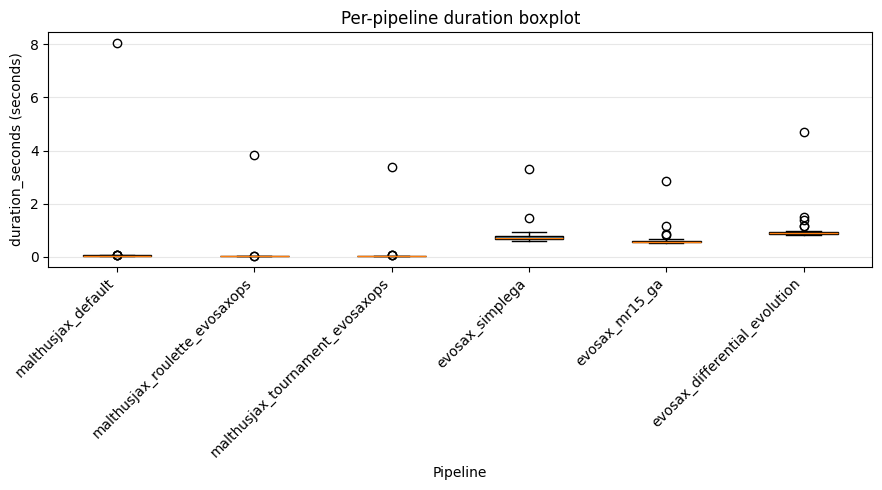

In [6]:
ax_box = comparison.plot_timing_boxplot(timing_key="duration_seconds")
ax_box.set_title("Per-pipeline duration boxplot")
ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


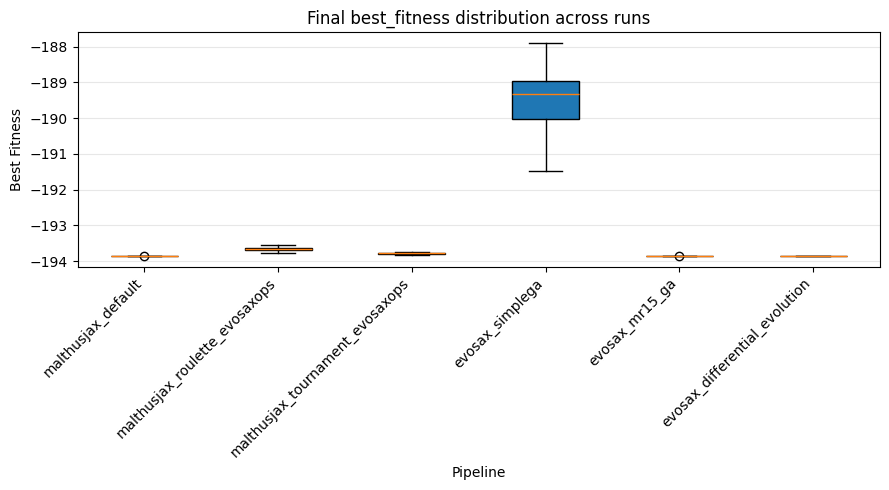

In [7]:
ax_final = comparison.plot_final_metric_boxplot(metric_key="best_fitness")
ax_final.set_title("Final best_fitness distribution across runs")
ax_final.set_xticklabels(ax_final.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
comparison.summary_table(latex=True)

'\\begin{tabular}{lrrrrrr}\n\\hline\nPipeline & initial\\_fitness & best\\_fitness & final\\_generation & total\\_evaluations & total\\_generations & pop\\_size \\\\\n\\hline\nmalthusjax\\_default & 167.816 & -193.855 & 100 & 10000 & nan & nan \\\\\nmalthusjax\\_roulette\\_evosaxops & 167.816 & -193.66 & 100 & 10000 & nan & nan \\\\\nmalthusjax\\_tournament\\_evosaxops & 167.816 & -193.779 & 100 & 10000 & nan & nan \\\\\nevosax\\_simplega & nan & -189.512 & 100 & 10000 & 100 & 100 \\\\\nevosax\\_mr15\\_ga & nan & -193.854 & 100 & 10000 & 100 & 100 \\\\\nevosax\\_differential\\_evolution & nan & -193.853 & 100 & 10000 & 100 & 100 \\\\\n\\hline\n\\end{tabular}'

In [9]:
comparison.convergence_data()

{'malthusjax_default': [{'generation': 1,
   'best_fitness': -175.6736297607422,
   'mean_fitness': -79.33216857910156},
  {'generation': 2,
   'best_fitness': -172.38584899902344,
   'mean_fitness': -114.28995513916016},
  {'generation': 3,
   'best_fitness': -184.95281982421875,
   'mean_fitness': -136.68035888671875},
  {'generation': 4,
   'best_fitness': -184.50257873535156,
   'mean_fitness': -153.42648315429688},
  {'generation': 5,
   'best_fitness': -191.96575927734375,
   'mean_fitness': -168.0585479736328},
  {'generation': 6,
   'best_fitness': -190.0648956298828,
   'mean_fitness': -179.27915954589844},
  {'generation': 7,
   'best_fitness': -190.6892547607422,
   'mean_fitness': -184.0914764404297},
  {'generation': 8,
   'best_fitness': -192.30564880371094,
   'mean_fitness': -187.11105346679688},
  {'generation': 9,
   'best_fitness': -192.63377380371094,
   'mean_fitness': -188.88710021972656},
  {'generation': 10,
   'best_fitness': -192.56483459472656,
   'mean_fitne